Multi-Target Wholesale Price Forecasting with Explainable LightGBM

**Project:** AI-Powered Agricultural Procurement Decision Support System  
**Task:** Multi-Output Regression (Predicting Next Month's Prices)  
**Targets:** `Min_Price_next`, `Avg_Price_next`, `Max_Price_next`  
**Model:** `lightgbm.LGBMRegressor` inside `MultiOutputRegressor`

In [51]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

print(f" LightGBM Version: {lgb.__version__}")
print(f" SHAP Version: {shap.__version__}")

 LightGBM Version: 4.7.0
 SHAP Version: 0.49.1


In [52]:
# Load Feature-Engineered Dataset directly from Step 04
data_path = os.path.join('data', 'all_months_features.csv')

if os.path.exists(data_path):
    df_raw = pd.read_csv(data_path)
    print(f"✓ Feature dataset loaded successfully from '{data_path}'. Shape: {df_raw.shape}")
else:
    raise FileNotFoundError(f"File not found at '{data_path}'. Please run notebook 04 first.")

✓ Feature dataset loaded successfully from 'data/all_months_features.csv'. Shape: (798, 77)


In [53]:
#  Sort chronologically by product and month index to ensure alignment
df = df_raw.copy()
df['month_idx'] = df.groupby('Product_Name').cumcount() + 1
df = df.sort_values(by=['Product_Name', 'month_idx']).reset_index(drop=True)

In [54]:
# Create Next-Month Target Variables (t + 1)
targets_base = ['Min_Price', 'Avg_Price', 'Max_Price']
targets_next = ['Min_Price_next', 'Avg_Price_next', 'Max_Price_next']

for base_col, next_col in zip(targets_base, targets_next):
    df[next_col] = df.groupby('Product_Name')[base_col].shift(-1)


In [55]:
# Drop rows where future target is missing (Month 10 has no Month 11) and reset index
df = df.dropna(subset=targets_next).copy().reset_index(drop=True)

print(f"✓ Cleaned dataset for next-month forecasting shape: {df.shape}")

✓ Cleaned dataset for next-month forecasting shape: (641, 80)


In [ ]:
# Feature & Target Matrices Separation

# Metadata columns to exclude from predictors
non_feature_cols = [
    'Product_Name', 'Category', 'Unit', 'unit_canonical', 'month_name',
    'bs_year', 'bs_month'
] + targets_base + targets_next

feature_cols = [col for col in df.columns if col not in non_feature_cols]

# Build Feature (X) and Multi-Output Target (y) Matrices
X = df[feature_cols].copy()
y = df[targets_next].copy()

# Ensure strictly numeric float values for LightGBM
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"✓ Predictor Features (X): {X.shape[1]} columns")
print(f"✓ Target Variables (y): {list(y.columns)}")

✓ Predictor Features (X): 67 columns
✓ Target Variables (y): ['Min_Price_next', 'Avg_Price_next', 'Max_Price_next']


In [57]:
# Temporal Split:
# Train Set: Months 1–8
# Test Set: All remaining months (Months 9, 10, etc.)
train_mask = (df['month_idx'] <= 8).values
test_mask = (df['month_idx'] >= 9).values

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

# Naive Baseline: Predict Next Month's Price = Current Month's Base Price
y_baseline_df = df.loc[test_mask, targets_base].copy()
y_baseline_df = y_baseline_df.fillna(method='ffill').fillna(0)
y_baseline = y_baseline_df.values

# Clean NaNs in targets
y_train = y_train.fillna(0)
y_test = y_test.fillna(0)

print(f"✓ Training Samples (Months 1–8): {X_train.shape[0]} rows")
print(f"✓ Testing Samples (Months 9+): {X_test.shape[0]} rows")

✓ Training Samples (Months 1–8): 592 rows
✓ Testing Samples (Months 9+): 49 rows


In [ ]:
# Base LightGBM Regressor
lgb_base = lgb.LGBMRegressor(
    n_estimators=150,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model = MultiOutputRegressor(lgb_base)
model.fit(X_train, y_train)

# Predict for test set
y_pred_arr = model.predict(X_test)
y_pred_df = pd.DataFrame(y_pred_arr, columns=target_cols)

# Apply business domain post-processing constraint (Min <= Avg <= Max)
y_pred_df['Min_Price_next'] = np.minimum(y_pred_df['Min_Price_next'], y_pred_df['Avg_Price_next'])
y_pred_df['Max_Price_next'] = np.maximum(y_pred_df['Max_Price_next'], y_pred_df['Avg_Price_next'])

print("✓ LightGBM Multi-Target model training and post-processing complete.")


Training Multi-Output LightGBM Model...
✓ Model Training Complete.


In [59]:
# Evaluation Metrics Across All Testing Months (NaN-Safe)
# metrics = []

for i, col in enumerate(targets_next):
    y_true = y_test.iloc[:, i].values
    y_p = y_pred[:, i]
    y_b = y_baseline[:, i]

    # Mask valid non-NaN numeric pairs
    valid_mask = ~np.isnan(y_true) & ~np.isnan(y_b) & ~np.isnan(y_p)
    
    y_true_clean = y_true[valid_mask]
    y_p_clean = y_p[valid_mask]
    y_b_clean = y_b[valid_mask]

    # LightGBM Metrics
    lgb_mae = mean_absolute_error(y_true_clean, y_p_clean)
    lgb_rmse = np.sqrt(mean_squared_error(y_true_clean, y_p_clean))
    lgb_r2 = r2_score(y_true_clean, y_p_clean)
    
    # Naive Baseline Metrics
    base_mae = mean_absolute_error(y_true_clean, y_b_clean)
    base_rmse = np.sqrt(mean_squared_error(y_true_clean, y_b_clean))
    base_r2 = r2_score(y_true_clean, y_b_clean)
    
    metrics.append({
        'Target': col,
        'LGBM MAE': round(lgb_mae, 2),
        'Baseline MAE': round(base_mae, 2),
        'LGBM RMSE': round(lgb_rmse, 2),
        'Baseline RMSE': round(base_rmse, 2),
        'LGBM R2': round(lgb_r2, 4),
        'Baseline R2': round(base_r2, 4)
    })

df_metrics = pd.DataFrame(metrics)
print("\n--- Overall Model Performance Comparison (All Test Months) ---")
print(df_metrics.to_string(index=False))


--- Overall Model Performance Comparison (All Test Months) ---
        Target  LGBM MAE  Baseline MAE  LGBM RMSE  Baseline RMSE  LGBM R2  Baseline R2
Min_Price_next     29.54         27.04      63.75          64.31   0.6656       0.6597
Avg_Price_next     44.02         21.08      91.44          38.15   0.8627       0.9761
Max_Price_next     44.63         24.63      71.65          47.37   0.7177       0.8766
Min_Price_next     29.54         27.04      63.75          64.31   0.6656       0.6597
Avg_Price_next     44.02         21.08      91.44          38.15   0.8627       0.9761
Max_Price_next     44.63         24.63      71.65          47.37   0.7177       0.8766


In [60]:
# Month-by-Month Breakdown Comparison
# Performance breakdown per test month
test_df_eval = df.loc[test_mask, ['Product_Name', 'month_idx']].copy().reset_index(drop=True)

for month in sorted(test_df_eval['month_idx'].unique()):
    m_mask = (test_df_eval['month_idx'] == month).values
    print(f"\n--- Metrics for month_idx = {month} ({m_mask.sum()} commodities) ---")
    
    m_metrics = []
    for i, col in enumerate(targets_next):
        y_t_m = y_test.iloc[m_mask, i].values
        y_p_m = y_pred[m_mask, i]
        y_b_m = y_baseline[m_mask, i]
        
        m_metrics.append({
            'Target': col,
            'LGBM MAE': round(mean_absolute_error(y_t_m, y_p_m), 2),
            'Baseline MAE': round(mean_absolute_error(y_t_m, y_b_m), 2),
            'LGBM RMSE': round(np.sqrt(mean_squared_error(y_t_m, y_p_m)), 2)
        })
    print(pd.DataFrame(m_metrics).to_string(index=False))


--- Metrics for month_idx = 9 (49 commodities) ---
        Target  LGBM MAE  Baseline MAE  LGBM RMSE
Min_Price_next     29.54         27.04      63.75
Avg_Price_next     44.02         21.08      91.44
Max_Price_next     44.63         24.63      71.65


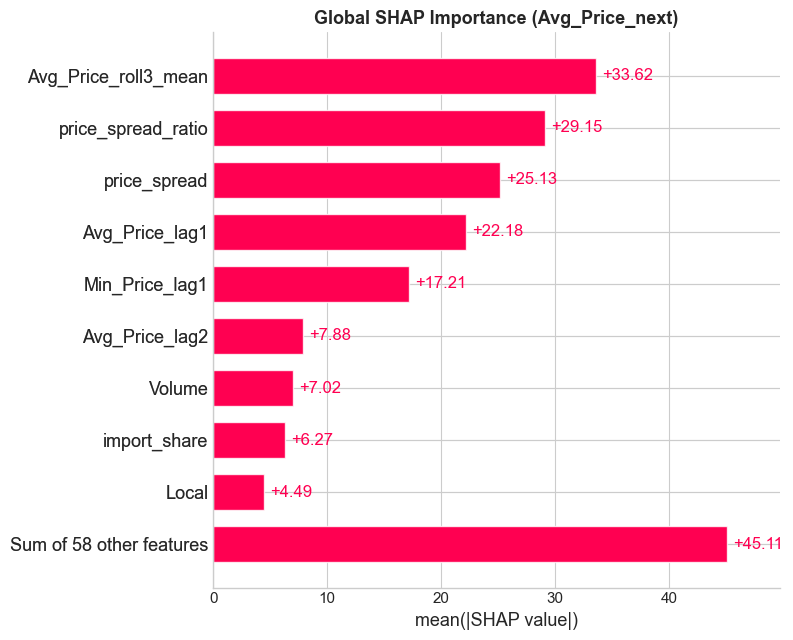

In [40]:
# Global Feature Importance
avg_model = model.estimators_[1] # Estimator for Avg_Price_next
explainer = shap.TreeExplainer(avg_model)
shap_values = explainer(X_test)

plt.figure(figsize=(10, 5))
shap.plots.bar(shap_values, max_display=10, show=False)
plt.title("Global SHAP Importance (Avg_Price_next)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

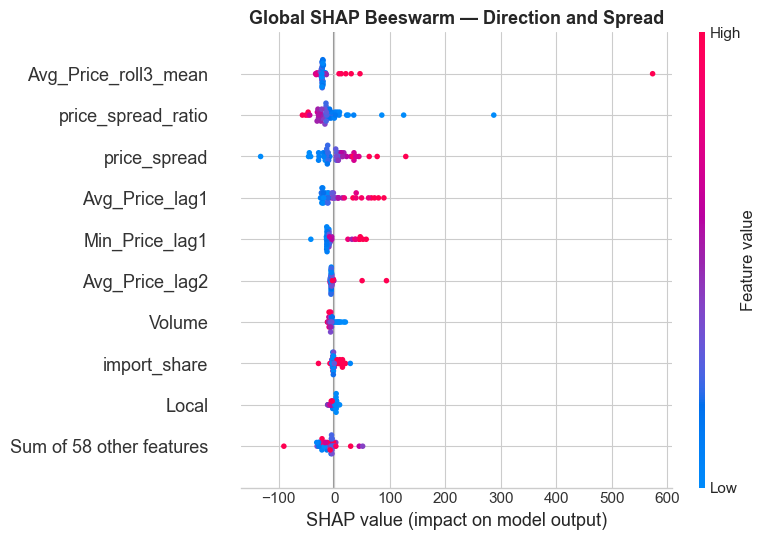

In [41]:
# Beeswarm Summary

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.title("Global SHAP Beeswarm — Direction and Spread", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

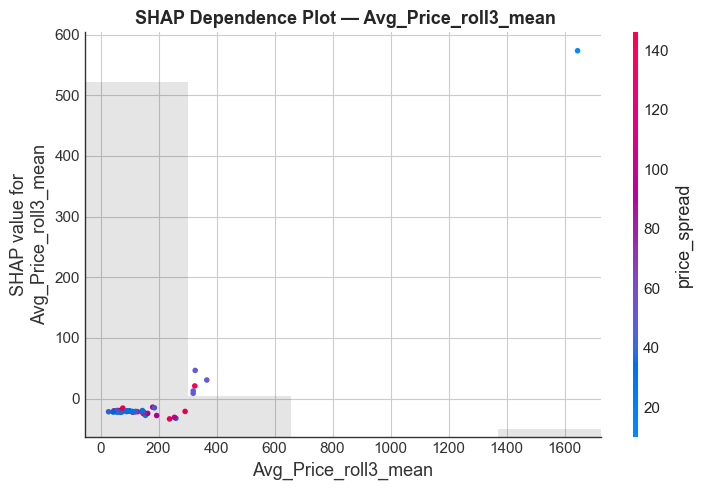

In [42]:
# Feature Dependence Scatter Plot

# Top numerical driver
top_feat = feature_cols[np.argmax(np.abs(shap_values.values).mean(0))]

plt.figure(figsize=(10, 5))
shap.plots.scatter(shap_values[:, top_feat], color=shap_values, show=False)
plt.title(f" SHAP Dependence Plot — {top_feat}", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

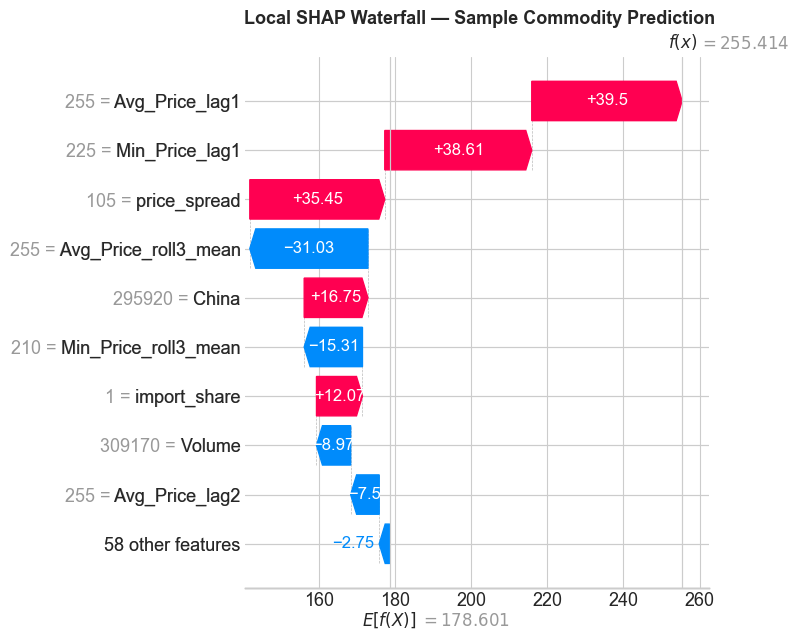

In [43]:
# Local Waterfall Plot

plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_values[0], max_display=10, show=False)
plt.title(" Local SHAP Waterfall — Sample Commodity Prediction", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Format test prediction output dataframe
results_df = df.loc[test_mask, ['Product_Name', 'month_idx']].copy()

for i, col in enumerate(targets_next):
    results_df[f'Actual_{col}'] = y_test.iloc[:, i].values
    results_df[f'Predicted_{col}'] = np.round(y_pred[:, i], 2)
    results_df[f'Baseline_{col}'] = y_baseline[:, i]

output_path = os.path.join('data', '06_testing_lightgbm_forecast_results.csv')
results_df.to_csv(output_path, index=False)

print(f"✓ Forecast results saved to '{output_path}'.")
print(results_df.head())

✓ Forecast results saved to 'data/06_testing_lightgbm_forecast_results.csv'.
      Product_Name  month_idx  Actual_Min_Price_next  \
20           Apple          9                  225.0   
35            Arum          9                   60.0   
44         Avocado          9                  650.0   
68    Banana_Green          9                  140.0   
90  Beat_Chukunder          9                   80.0   

    Predicted_Min_Price_next  Baseline_Min_Price_next  Actual_Avg_Price_next  \
20                    243.32                    225.0                 266.30   
35                     56.58                     60.0                  65.00   
44                    292.44                    300.0                 757.61   
68                    137.77                    180.0                 175.15   
90                     68.16                     80.0                 100.00   

    Predicted_Avg_Price_next  Baseline_Avg_Price_next  Actual_Max_Price_next  \
20                    255